In [1]:
import cv2 
import IPython
import numpy as np
from tqdm import tqdm 

In [2]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [3]:
def draw_faces(image, faces, threshold=0.5):
    for i in range(faces.shape[2]):
        confidence = faces[0, 0, i, 2]
        if confidence > threshold:
            (h, w) = image.shape[:2]
            box = faces[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            cv2.rectangle(image, (startX, startY), (endX, endY),
                (0, 0, 255), 2)

In [9]:
def detect_image(src, net):
    image = cv2.imread(src)
    (h, w) = image.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0,
        (300, 300), (104.0, 177.0, 123.0))
    net.setInput(blob)
    detections = net.forward()
    draw_faces(image, detections, threshold=0.5)
    show_image(image)
    return image

In [5]:
cv2.cuda.getCudaEnabledDeviceCount()

1

In [6]:
net = cv2.dnn.readNetFromCaffe('./data/deploy.prototxt', './data/res10_300x300_ssd_iter_140000.caffemodel')
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)

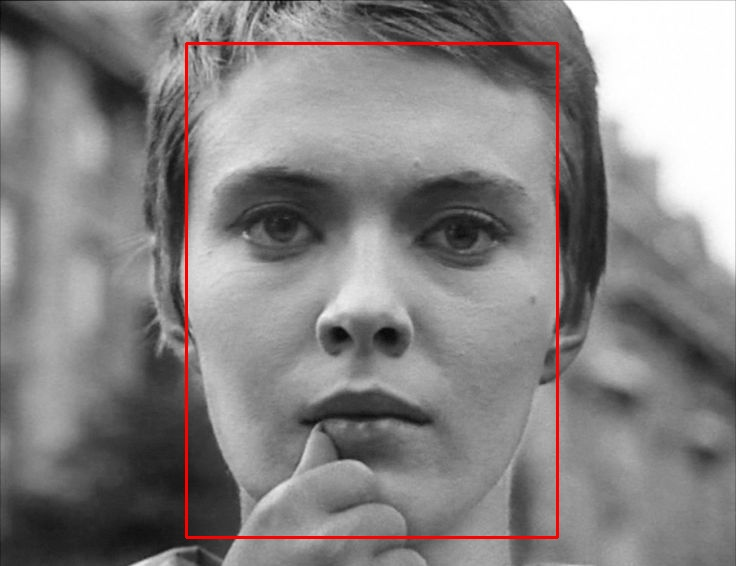

In [10]:
img = detect_image('./images/img_1.jpg', net)

In [12]:
cv2.imwrite('/home/amos/Documents/img.jpg', img)

True

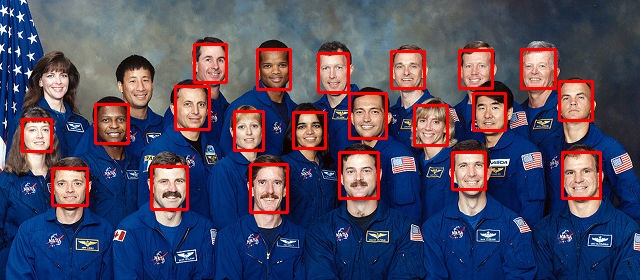

In [26]:
detect_image('./images/img_2.jpg', net)

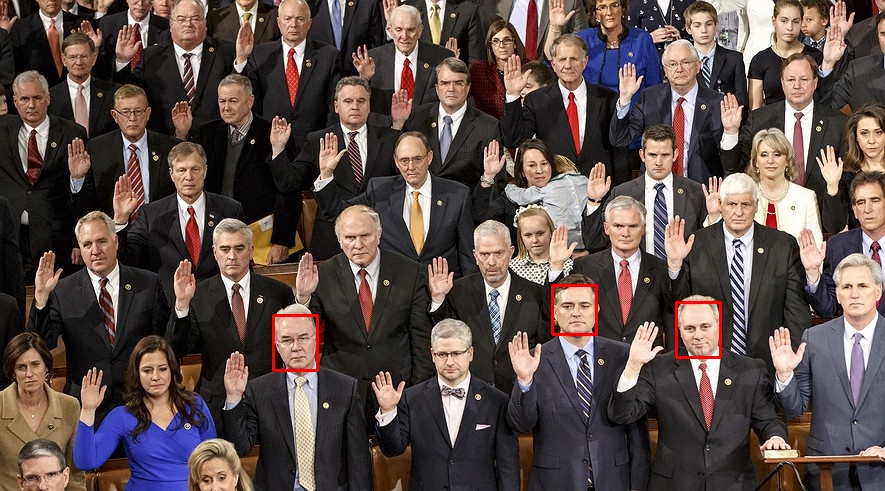

In [27]:
detect_image('./images/img_3.jpg', net)

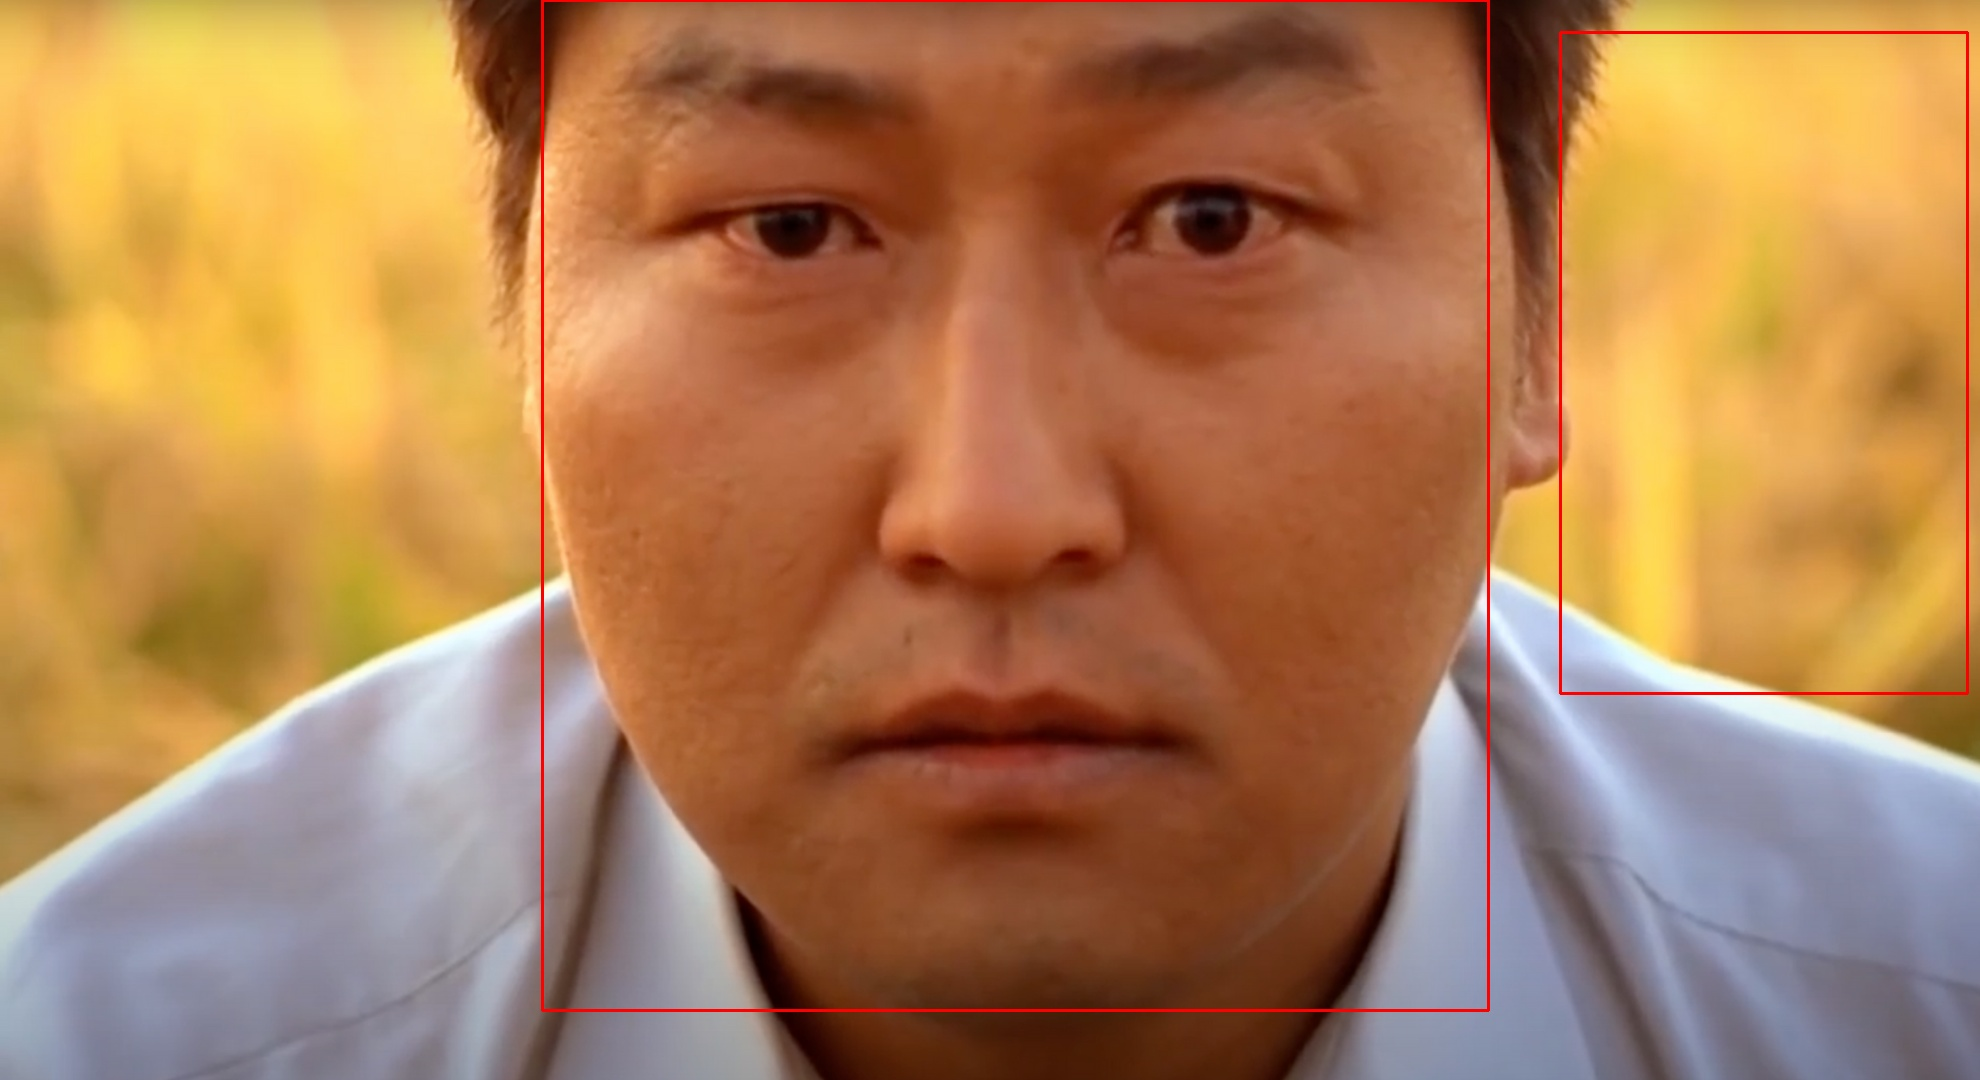

In [28]:
detect_image('./images/img_4.jpg', net)

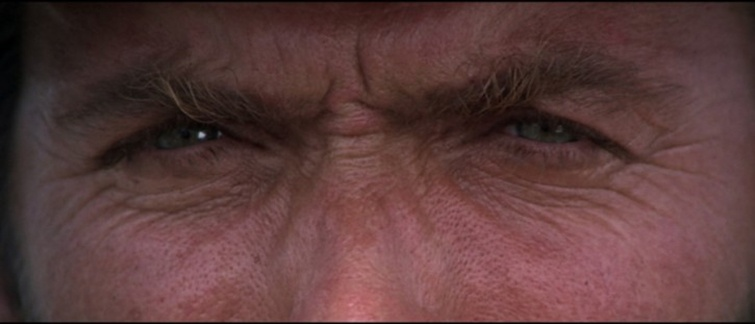

In [29]:
detect_image('./images/img_5.jpg', net)

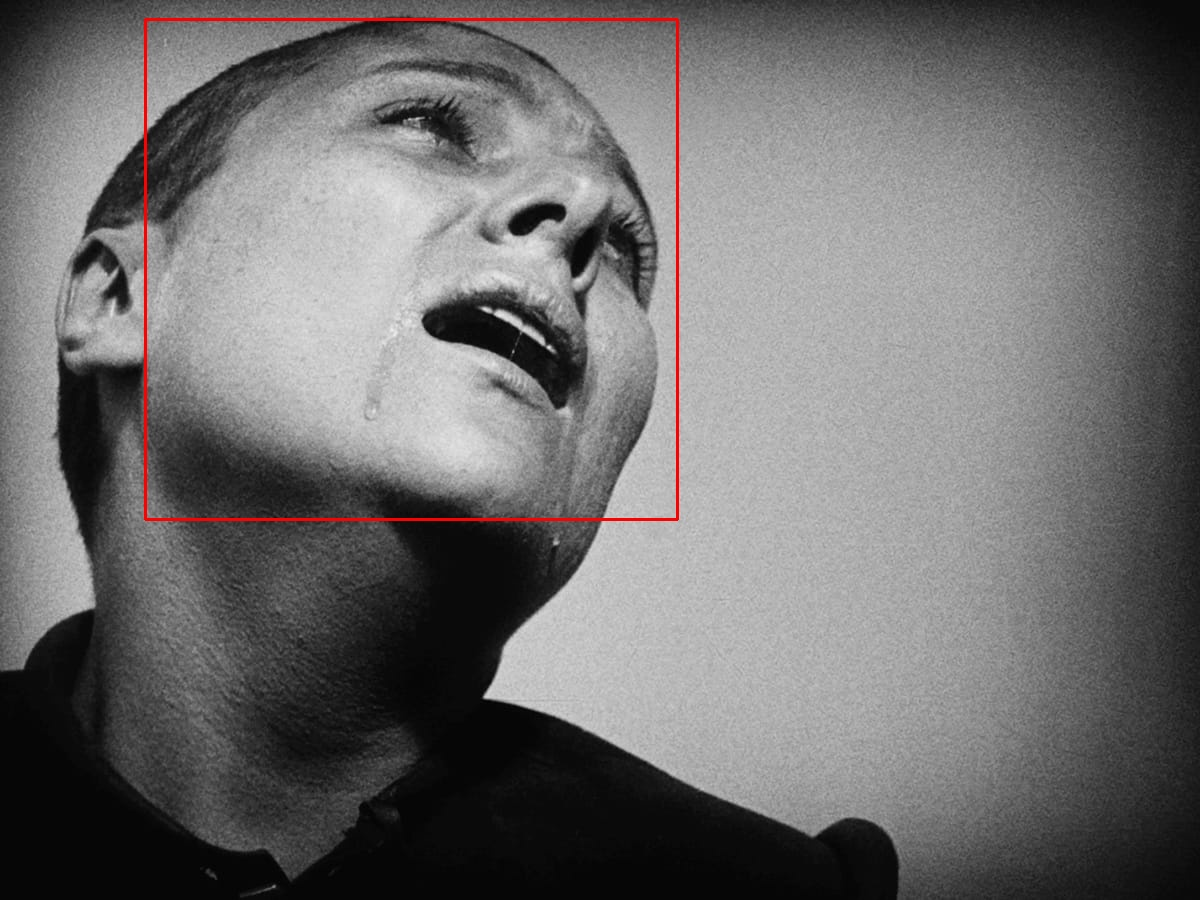

In [31]:
detect_image('./images/img_6.jpg', net)

In [20]:
cap = cv2.VideoCapture('./data/test.mkv')
ret, _ = cap.read()
print(ret)

True


  0%|          | 0/111290 [00:03<?, ?it/s]


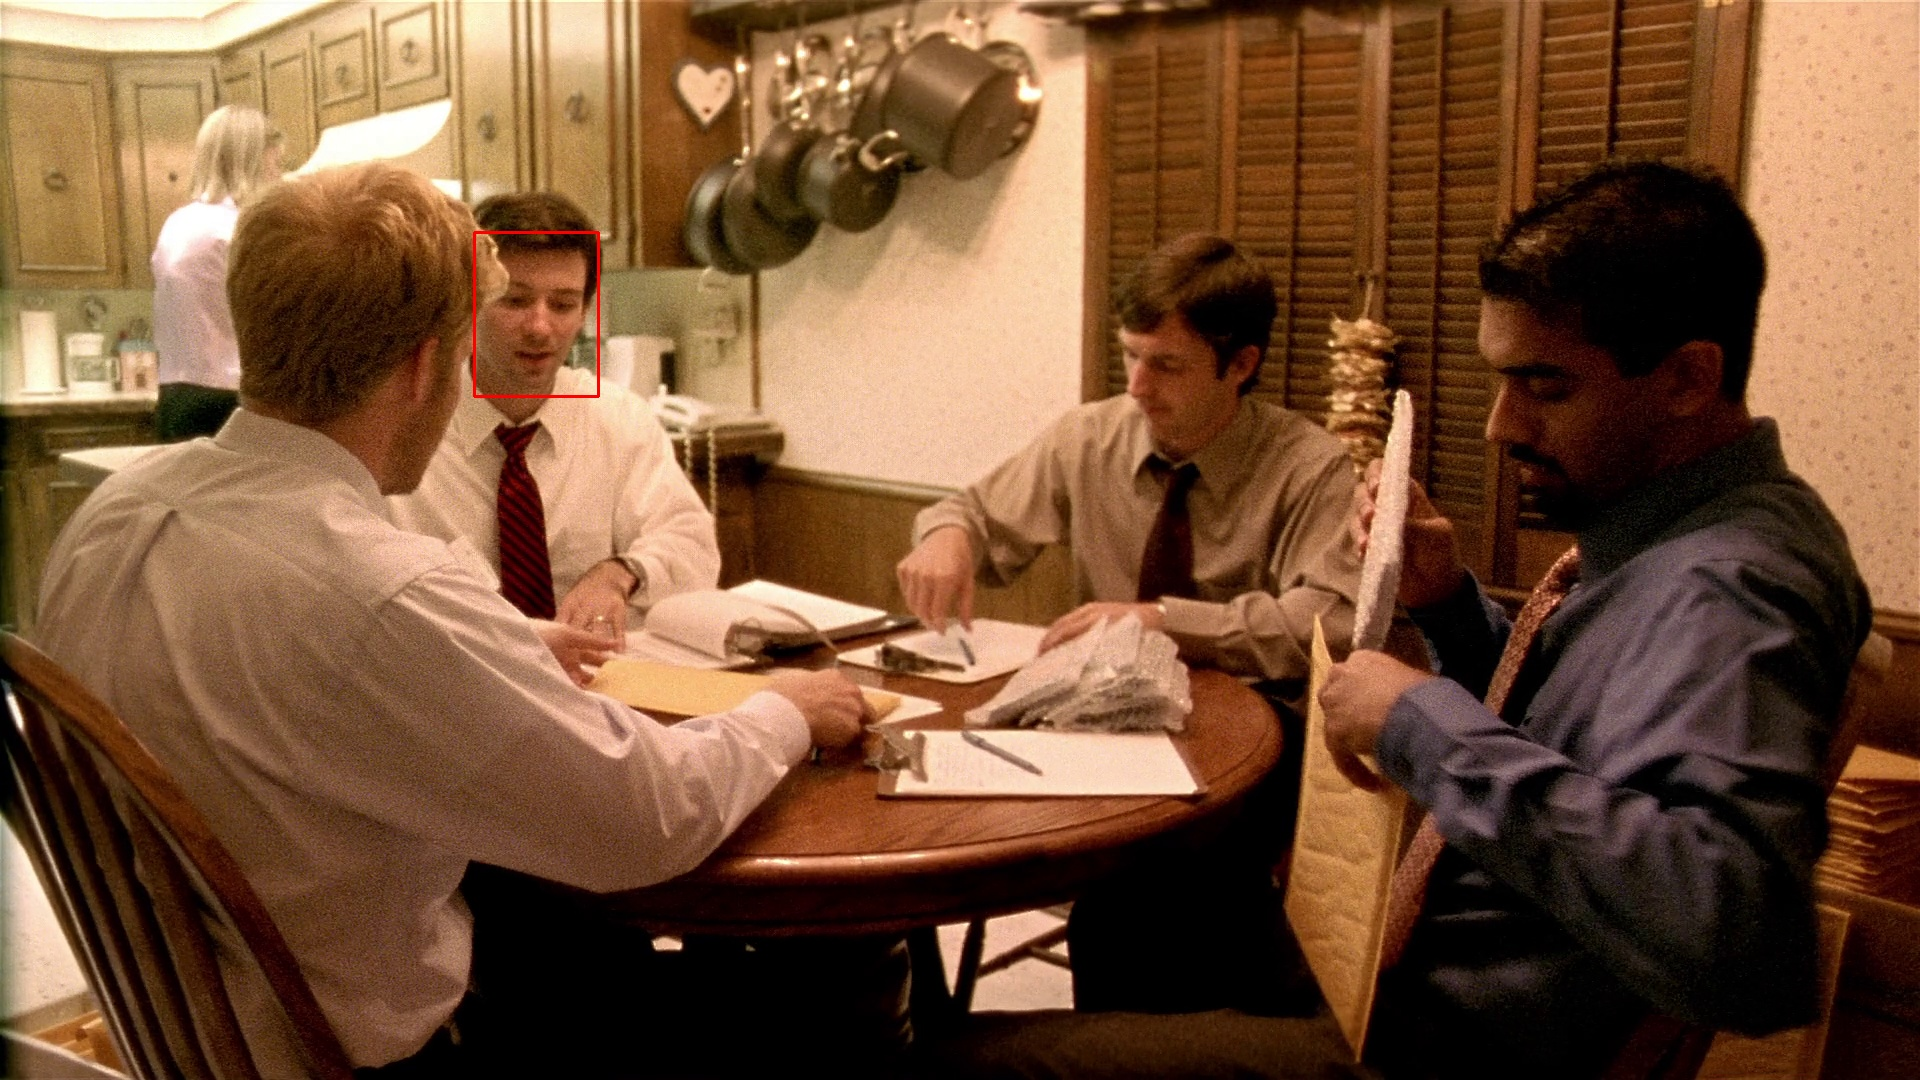

48


In [23]:
cnt = 0
_, _ = cap.read()
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
while True:
    if cnt % 24 == 0:
        _, frame = cap.read()
        (h, w) = frame.shape[:2]
        blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 1.0,
            (300, 300), (104.0, 177.0, 123.0))
        net.setInput(blob)
        detections = net.forward()
        faces = np.array([detections[:, :, x, :] for x in range(detections.shape[2]) if detections[0, 0, x, 2] > 0.5])
        if len(faces) > 1:
            draw_faces(frame, faces)
            show_image(frame)
            break
        else:
            cnt += 1
            pb.update(1)
            continue
    cnt = cnt + 1
    pb.update(1)
print(cnt)

In [15]:
faces

[]